In [317]:
import pandas as pd
import numpy as np
from matplotlib.lines import lineStyles

In [318]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("fivethirtyeight")

In [319]:
df = pd.read_csv("dataset/TelcoCustomerChurn.csv")

In [320]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [321]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [322]:
df.drop(columns=["customerID"],inplace=True)

In [323]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [324]:
for col in df.columns:
    if col not in ["tenure" , "MonthlyCharges" , "TotalCharges"]:
        print(col , df[col].unique())
        print("-----------------------")

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
-----------------------
SeniorCitizen [0 1]
-----------------------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
-----------------------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
-----------------------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
-----------------------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
-----------------------
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
-----------------------
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
-----------------------
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
-----------------------
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
-----------------------
TechSupport <StringArray>
['No', 'Yes', 'No internet service']
Leng

In [325]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [326]:
for col in df.columns:
    if col not in ["tenure" , "MonthlyCharges" , "TotalCharges"]:
        print(col , len(df[df[col]==" "]))
        print("-----------------------")

gender 0
-----------------------
SeniorCitizen 0
-----------------------
Partner 0
-----------------------
Dependents 0
-----------------------
PhoneService 0
-----------------------
MultipleLines 0
-----------------------
InternetService 0
-----------------------
OnlineSecurity 0
-----------------------
OnlineBackup 0
-----------------------
DeviceProtection 0
-----------------------
TechSupport 0
-----------------------
StreamingTV 0
-----------------------
StreamingMovies 0
-----------------------
Contract 0
-----------------------
PaperlessBilling 0
-----------------------
PaymentMethod 0
-----------------------
Churn 0
-----------------------


In [327]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0.0").astype(float)

In [328]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [329]:
df.shape

(7043, 20)

In [330]:
def plot_distribution(df , column_name):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[column_name] , kde = True)
    plt.title(f"Distribution of {column_name}")
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean,color="red" , linestyle = "--",label="Mean")
    plt.axvline(col_median,color="blue" , linestyle = "--",label="Median")
    plt.legend()
    plt.subplot(1,2,2)
    sns.boxplot(y = df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.show()

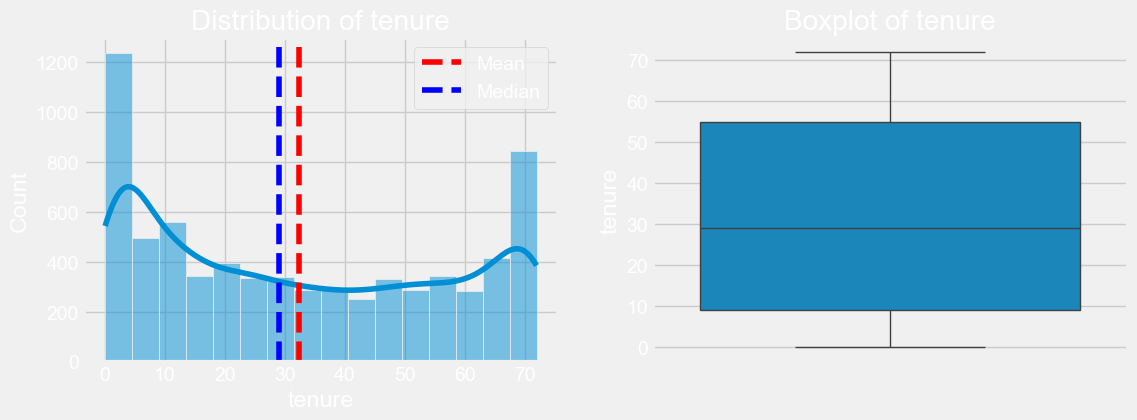

In [331]:
plot_distribution(df , "tenure")

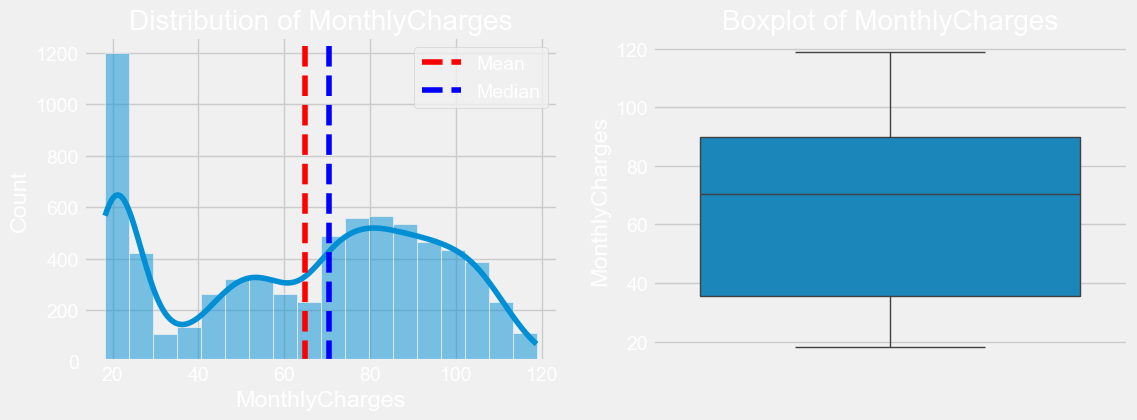

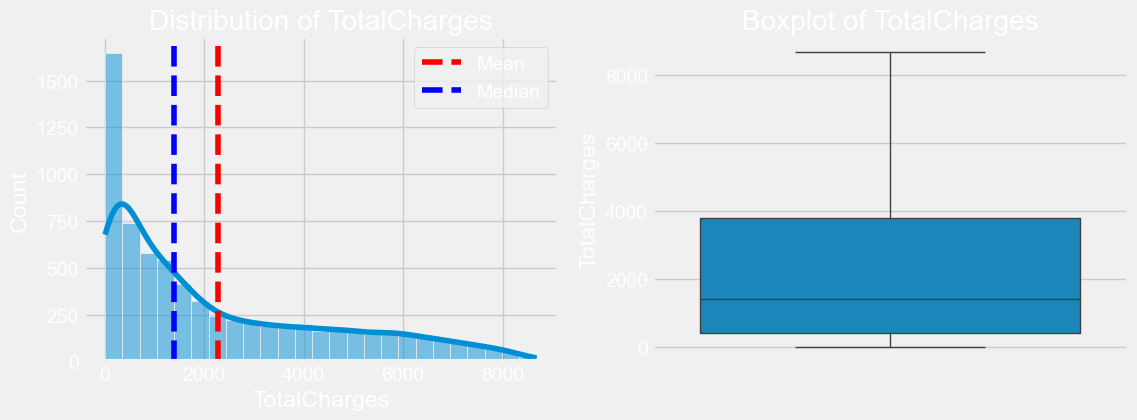

In [332]:
plot_distribution(df , "MonthlyCharges")
plot_distribution(df , "TotalCharges")

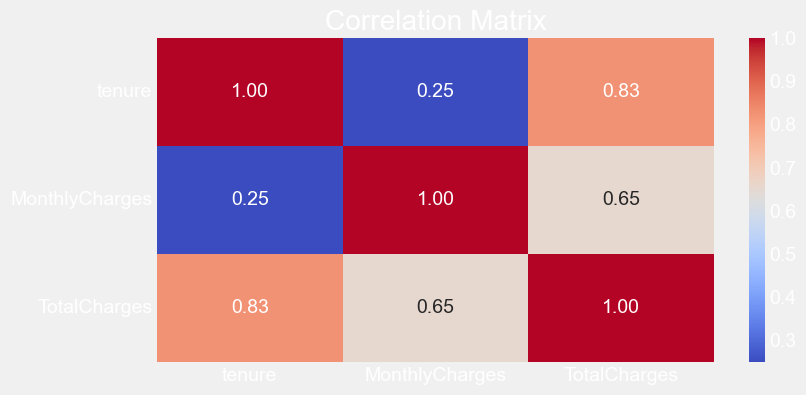

In [333]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure" , "MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

/var/folders/5f/khgd2s3j233ft2hlcsl3fx9c0000gn/T/ipykernel_40810/1198444367.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = "object").columns.to_list() + ['SeniorCitizen']


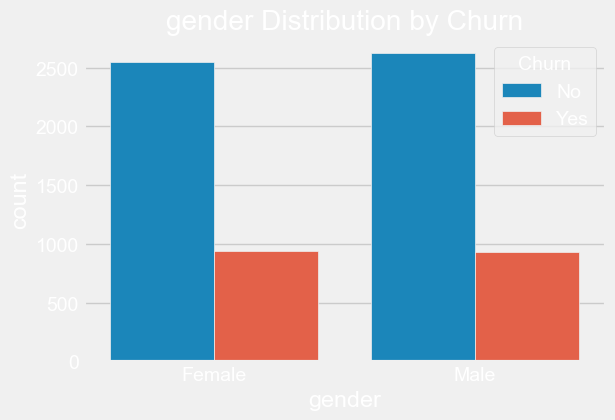

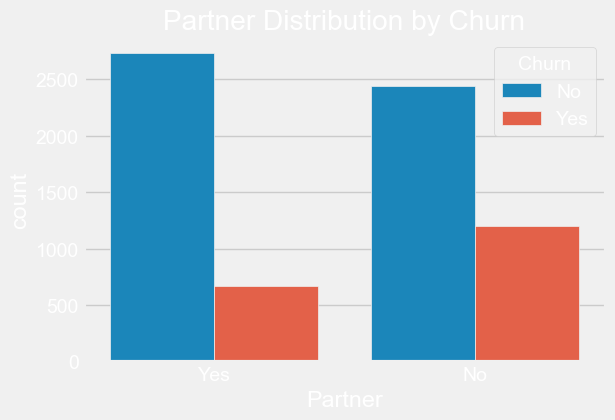

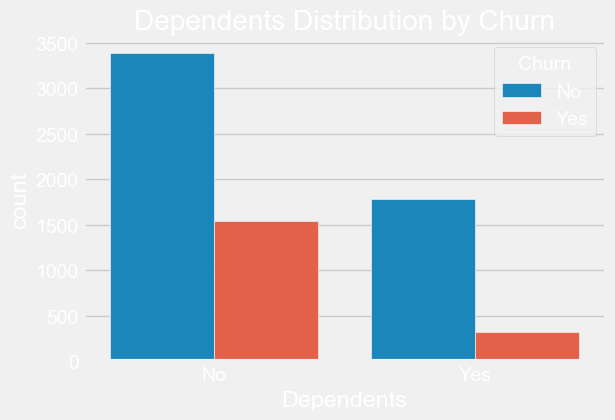

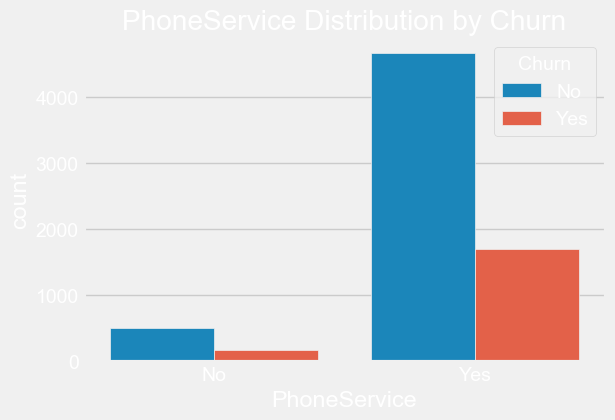

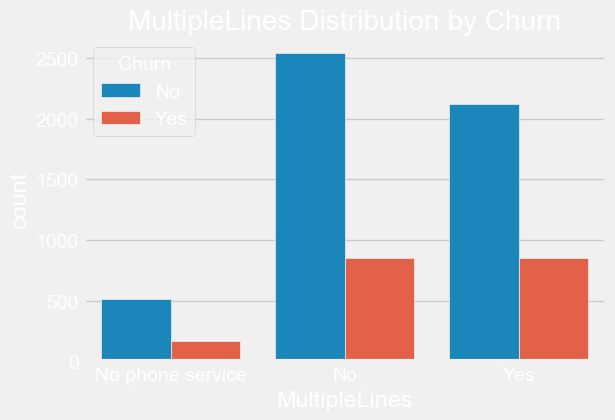

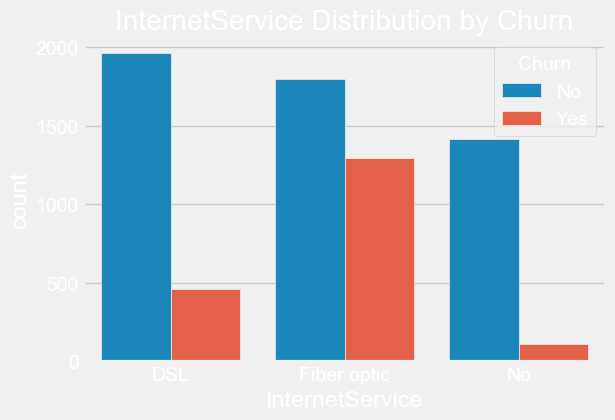

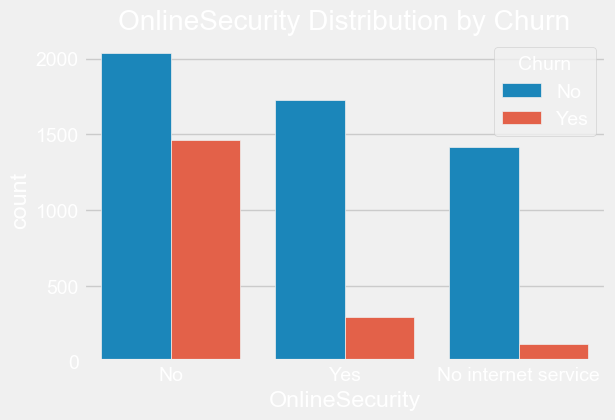

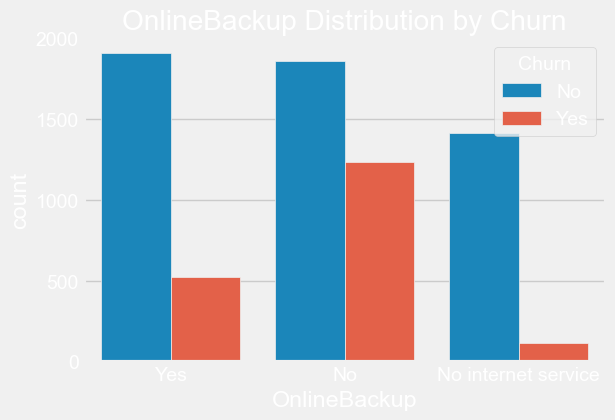

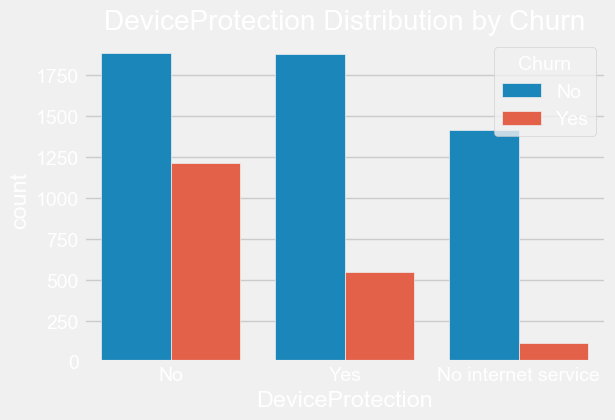

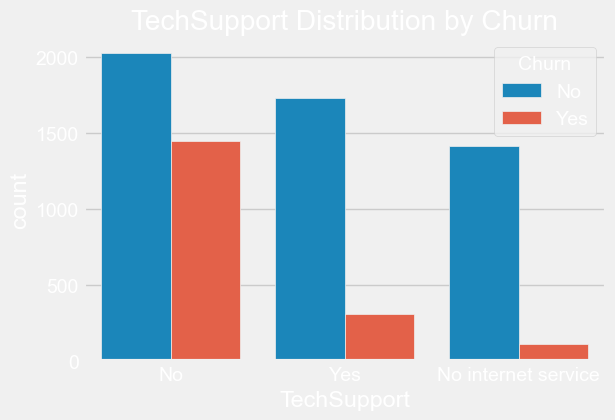

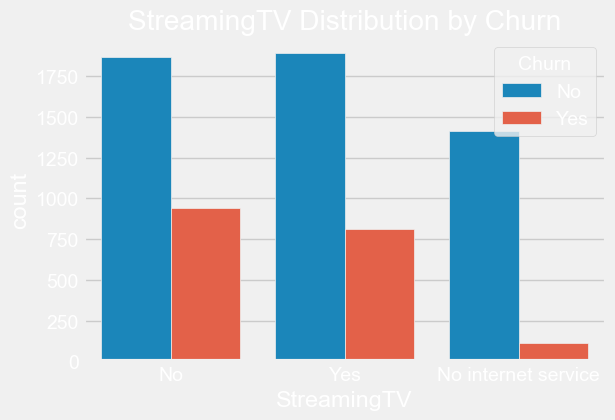

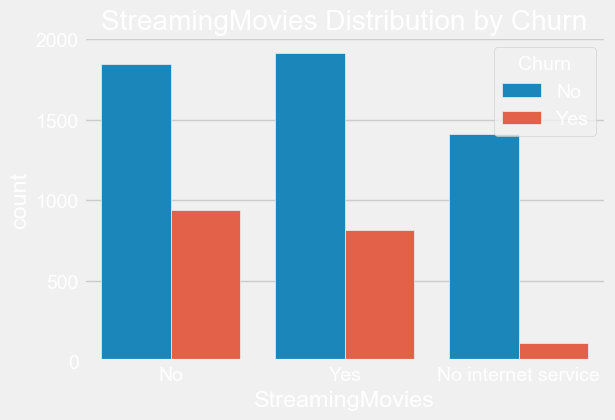

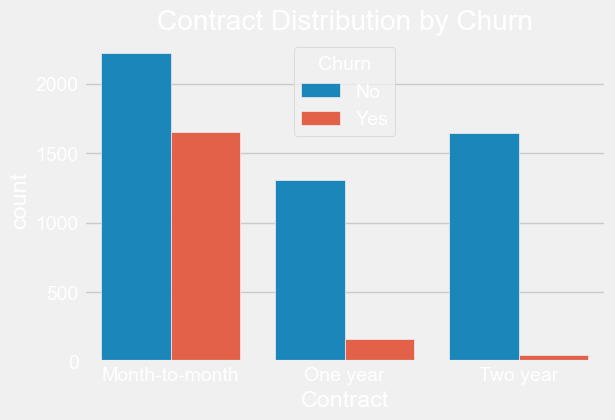

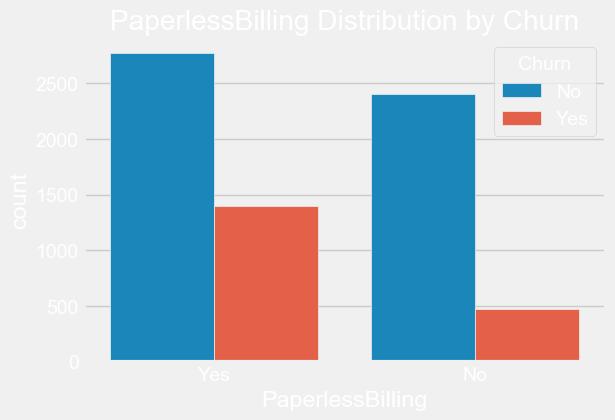

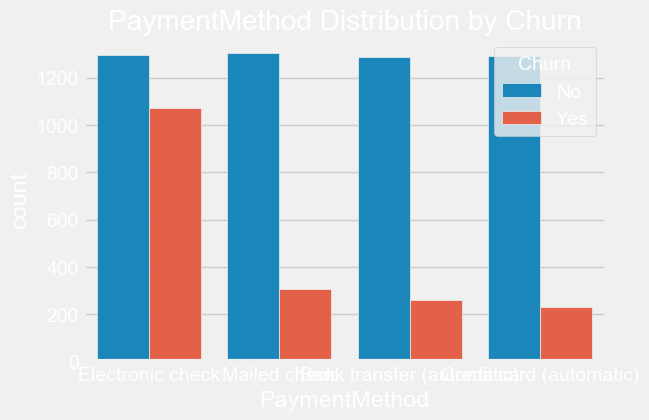

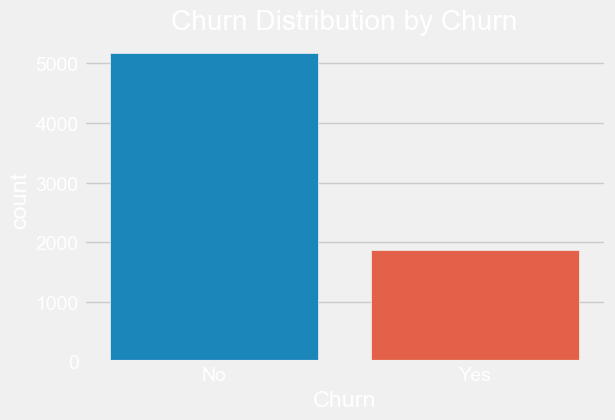

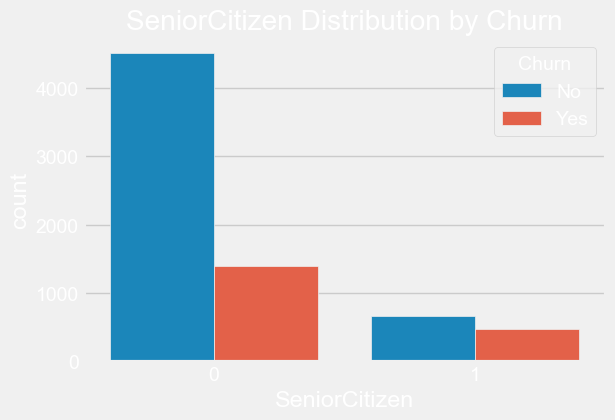

In [334]:
categorical_cols = df.select_dtypes(include = "object").columns.to_list() + ['SeniorCitizen']
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data = df , x = col , hue = "Churn")
    plt.title(f"{col} Distribution by Churn")
    plt.show()

In [335]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)

In [336]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [337]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)

# 2. Select columns (Explicitly excluding Churn just to be safe)
objects_columns = df.select_dtypes(include=["object", "string"]).columns
if 'Churn' in objects_columns:
    objects_columns = objects_columns.drop('Churn')

In [338]:
objects_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [339]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for column in objects_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

In [340]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [341]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  
 17  Monthl

In [342]:
import pickle
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [343]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['tenure' , 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [344]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [345]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score

In [346]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [347]:
y_train.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

In [348]:
smote = SMOTE(random_state=42)

In [349]:
X_train_smote , y_train_smote = smote.fit_resample(X_train,y_train)

In [350]:
y_train_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [351]:
models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42),
}

In [352]:
hyperparameters = {
    "Random Forest":{
        "n_estimators" : [50,100,200],
        "max_depth":[5,10,None],
    },
    "XGBoost":{
        "learning_rate" : [0.01,0.1,0.2],
        "max_depth":[3,5,7],
    }
}

In [353]:

best_models = {}
for model_name , model in models.items():
    print(f"Tuning {model_name}........")
    grid = GridSearchCV(estimator=model , param_grid=hyperparameters[model_name],cv=3 , scoring = "accuracy")
    grid.fit(X_train_smote,y_train_smote)
    best_models[model_name] = grid.best_estimator_
    print(f"Best parameters for {model_name} : {grid.best_params_}")
    print(f"Best score for {model_name} : {grid.best_score_:.2f}\n")

Tuning Random Forest........
Best parameters for Random Forest : {'max_depth': None, 'n_estimators': 200}
Best score for Random Forest : 0.83

Tuning XGBoost........
Best parameters for XGBoost : {'learning_rate': 0.2, 'max_depth': 7}
Best score for XGBoost : 0.81



In [354]:
best_models

{'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)}

In [355]:
with open("best_model.pkl","wb") as f:
    pickle.dump(best_models["Random Forest"],f)

In [356]:
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

In [357]:
y_test_pred = best_models['Random Forest'].predict(X_test)
y_test_prob = best_models['Random Forest'].predict_proba(X_test)

In [358]:
print(f"Accuracy:",accuracy_score(y_test,y_test_pred)*100)
print(f"ROC-AUC Score:",roc_auc_score(y_test,y_test_pred)*100)
print(f"Confusion Matrix:",confusion_matrix(y_test,y_test_pred)*100)
print(f"Classification Report:",classification_report(y_test,y_test_pred)*100)

Accuracy: 78.14052519517388
ROC-AUC Score: 74.58349291459211
Confusion Matrix: [[85100 18500]
 [12300 25000]]
Classification Report:               precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.67      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.67      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.67      0.62       373

    accuracy                           0.78      14

In [359]:
with open("best_model.pkl" , "rb") as f:
    loaded_model = pickle.load(f)
with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler_data = pickle.load(f)

In [360]:
def make_predictions(input_data):
    input_df = pd.DataFrame([input_data])
    for col , encoder in encoders.items():
        input_df[col] = encoder.transform(input_df[col])
    numerical_cols = ['tenure' , 'MonthlyCharges', 'TotalCharges']
    input_df[numerical_cols] = scaler_data.transform(input_df[numerical_cols])
    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0,1]
    return "Churn" if prediction == 1 else "No Churn" , probability

In [361]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [365]:
example_input = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

In [366]:
prediction , probability = make_predictions(example_input)

In [369]:
print(f"Prediction: {prediction}, Probability : {probability : .2f}")

Prediction: No Churn, Probability :  0.26
